# EDA

## Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# use seaborn theme (compatible across seaborn/matplotlib versions)
sns.set_theme(style="darkgrid")

# Load Cleaned Data

In [22]:
DATA_PATH = "../data/processed/cleaned_data.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
print("Shape : ", df.shape)
df.head()

Shape :  (72946, 9)


,open,high,low,close,volume,marketCap,crypto_name,date,log_return
0,-0.166334,-0.165950,-0.166175,-0.166323,-0.229533,-0.196627,Aave,2020-10-02,NaN
1,-0.166234,-0.153949,-0.166072,-0.156269,-0.229533,-0.196627,Aave,2020-10-03,53.253110
2,-0.156169,-0.155845,-0.156195,-0.156360,-0.229533,-0.196627,Aave,2020-10-04,-0.118554
3,-0.156265,-0.155837,-0.156373,-0.156256,-0.229533,-0.195439,Aave,2020-10-05,0.103119
4,-0.156147,-0.156154,-0.158155,-0.158323,-0.229472,-0.195681,Aave,2020-10-06,-2.627287


# Basic Dataset Summary

In [23]:
df.info()
print("\n\n ------------------------------------------------------------ \n\n")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   open         72946 non-null  float64       
 1   high         72946 non-null  float64       
 2   low          72946 non-null  float64       
 3   close        72946 non-null  float64       
 4   volume       72946 non-null  float64       
 5   marketCap    72946 non-null  float64       
 6   crypto_name  72946 non-null  object        
 7   date         72946 non-null  datetime64[ns]
 8   log_return   72890 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 5.0+ MB


 ------------------------------------------------------------ 




,open,high,low,close,volume,marketCap,date,log_return
count,72946.000000,72946.000000,7.294600e+04,7.294600e+04,7.294600e+04,7.294600e+04,72946,7.289000e+04
mean,0.000000,0.000000,4.363819e-17,2.493611e-17,1.558507e-17,2.181910e-17,2019-10-13 03:20:59.945713152,1.213645e-17
min,-0.166334,-0.166046,-1.661748e-01,-1.664214e-01,-2.295330e-01,-1.966272e-01,2013-05-05 00:00:00,-9.792052e+01
25%,-0.166302,-0.166013,-1.661436e-01,-1.663893e-01,-2.286679e-01,-1.941470e-01,2018-09-08 00:00:00,-3.180132e-01
50%,-0.166022,-0.165728,-1.658713e-01,-1.661082e-01,-2.181089e-01,-1.797159e-01,2020-03-17 00:00:00,-1.504039e-02
75%,-0.161350,-0.160939,-1.612939e-01,-1.614072e-01,-1.599601e-01,-1.283891e-01,2021-05-02 00:00:00,2.934284e-01
max,12.745490,29.876740,1.291791e+01,1.273916e+01,3.626189e+01,1.679862e+01,2022-10-23 00:00:00,5.957505e+01
std,1.000007,1.000007,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,NaN,1.000007e+00


# Number of Cryptocurrencies

In [24]:
df["crypto_name"].nunique()
df["crypto_name"].value_counts().head()

crypto_name
Bitcoin     3248
Litecoin    3248
XRP         3157
Dogecoin    3024
Monero      2866
Name: count, dtype: int64

#  Price Trend over time 

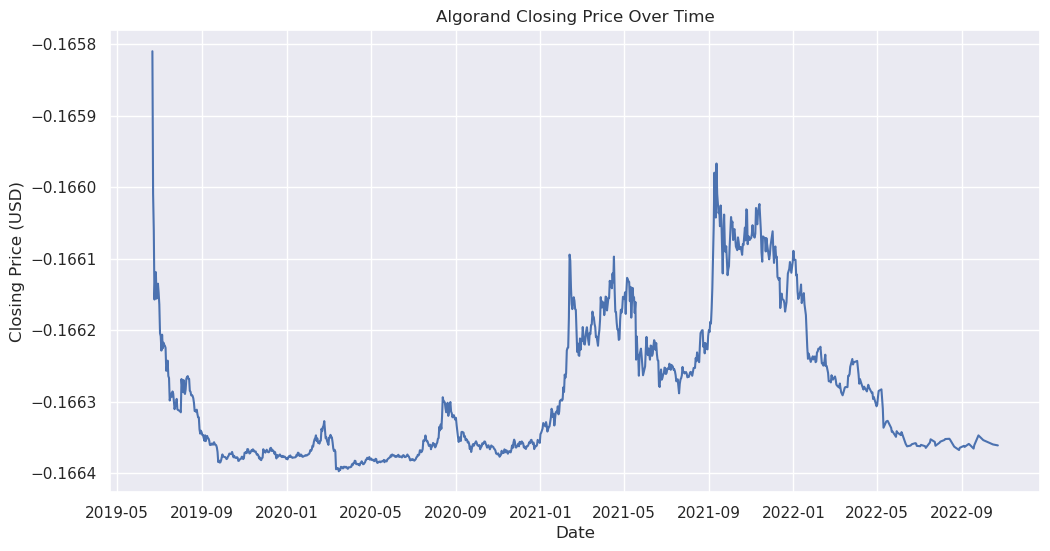

In [25]:
crypto = df["crypto_name"].unique()[1]

subset = df[df["crypto_name"] == crypto]
plt.figure(figsize=(12, 6))
plt.plot(subset["date"], subset["close"])
plt.title(f"{crypto} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.show()

/home/mrityunjay/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


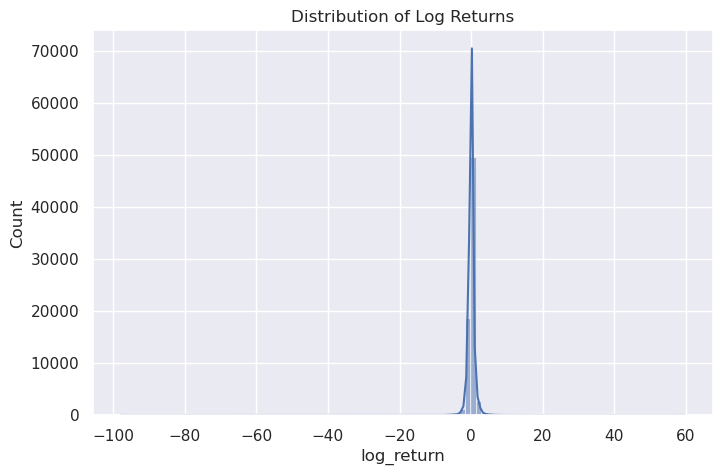

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df["log_return"].dropna(), bins=100, kde=True)
plt.title("Distribution of Log Returns")
plt.show()

Returns show fat tails and non-normal behavior — common in financial markets.

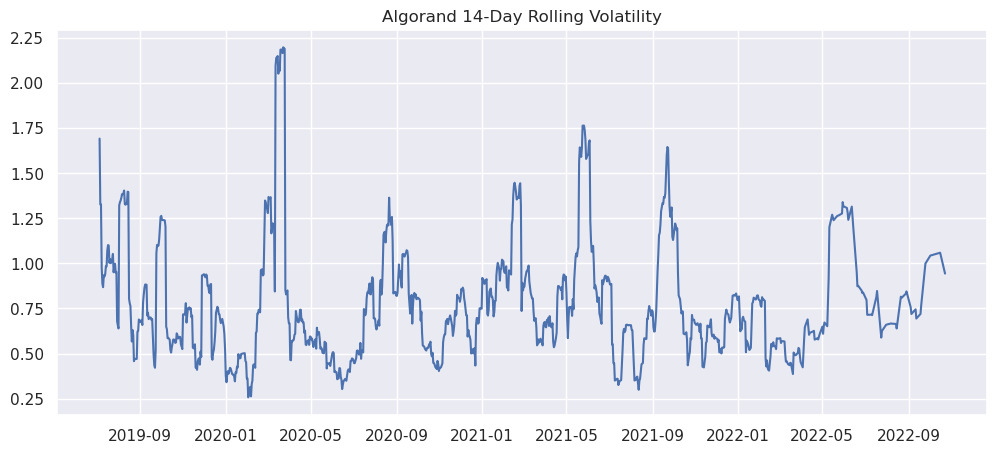

In [27]:
df["rolling_volatility_14"] = (
    df.groupby("crypto_name")["log_return"]
    .transform(lambda x: x.rolling(14).std())
)

subset = df[df["crypto_name"] == crypto]

plt.figure(figsize=(12,5))
plt.plot(subset["date"], subset["rolling_volatility_14"])
plt.title(f"{crypto} 14-Day Rolling Volatility")
plt.show()


Volatility clustering is observed — high volatility periods follow high volatility periods.

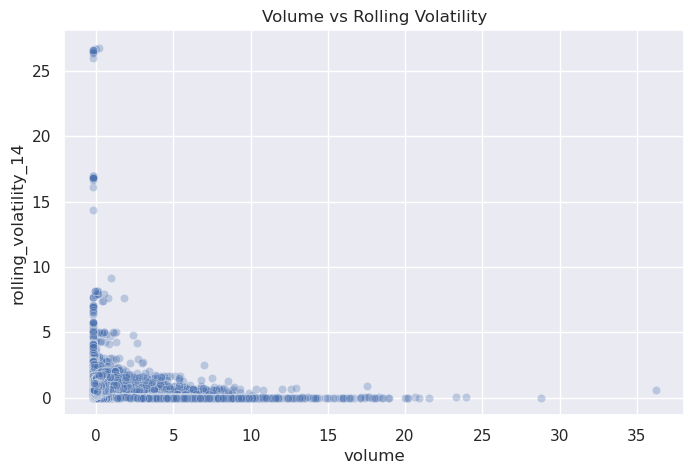

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["volume"],
    y=df["rolling_volatility_14"],
    alpha=0.3
)
plt.title("Volume vs Rolling Volatility")
plt.show()


Higher trading volume is often associated with increased volatility.

# Correlation Heatmap

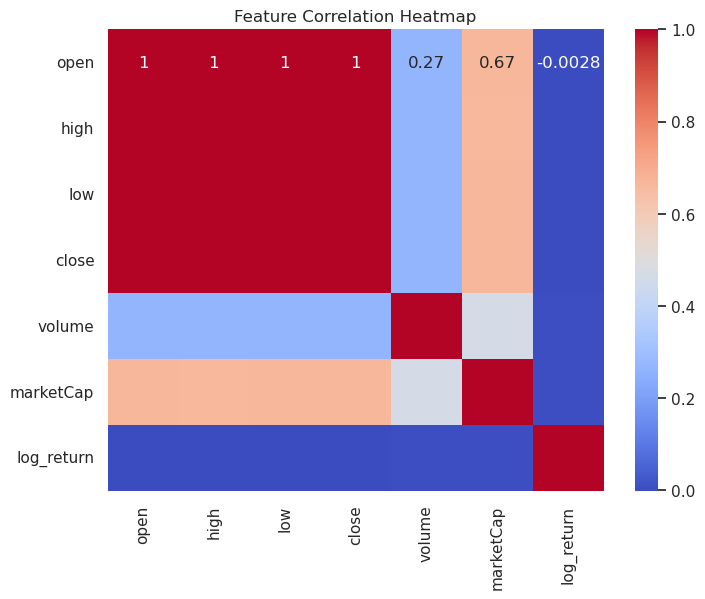

In [29]:
corr = df[[
    "open", "high", "low", "close",
    "volume", "marketCap",
    "log_return"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


High correlation among OHLC prices
Volume moderately correlated with returns
MarketCap strongly correlated with price

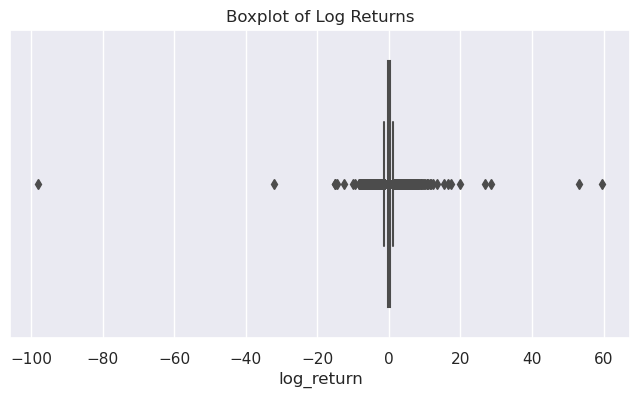

In [30]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["log_return"])
plt.title("Boxplot of Log Returns")
plt.show()


Extreme outliers present — confirms high-risk nature of crypto markets.

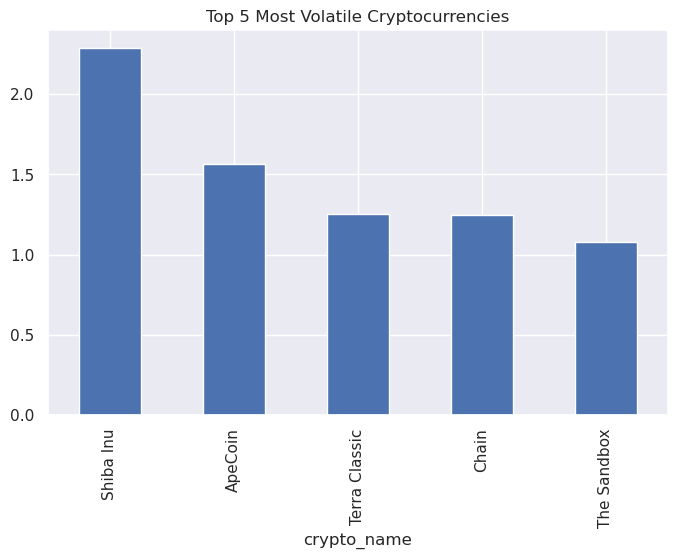

In [31]:
volatility_summary = (
    df.groupby("crypto_name")["rolling_volatility_14"]
    .mean()
    .sort_values(ascending=False)
    .head()
)

volatility_summary.plot(kind="bar", figsize=(8,5))
plt.title("Top 5 Most Volatile Cryptocurrencies")
plt.show()
